# HW4: SNN with STDP — Simulation & Weight Map Analysis

In [280]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Compile and run simulation
result = subprocess.run(
    ["bash", "-c", "cd /Users/dakotabarnes/Develop/274/hw4 && iverilog -o snn_sim snn_stdp.v tb_snn_stdp.v && vvp snn_sim"],
    capture_output=True, text=True
)
output = result.stdout
print(output)

VCD info: dumpfile snn_stdp.vcd opened for output.

=== Initial Weight Maps ===
  Weight map to Output Neuron 1:
    1 0 0 1 2 
    0 3 2 3 0 
    2 2 1 3 3 
    1 3 0 0 2 
    3 1 1 0 1 
  Weight map to Output Neuron 2:
    0 2 3 0 1 
    2 0 2 0 0 
    1 2 3 1 2 
    0 1 1 0 1 
    2 3 1 3 0 
DATA_W1 initial 1 0 0 1 2 0 3 2 3 0 2 2 1 3 3 1 3 0 0 2 3 1 1 0 1
DATA_W2 initial 0 2 3 0 1 2 0 2 0 0 1 2 3 1 2 0 1 1 0 1 2 3 1 3 0

=== Phase 1: Training with digit 0 ===
  t= 1: V1=  6 V2=  6 spike1=0 spike2=0
  t= 2: V1=  6 V2=  6 spike1=0 spike2=0
  t= 3: V1= 41 V2= 37 spike1=0 spike2=0
  t= 4: V1= 41 V2= 37 spike1=0 spike2=0
  t= 5: V1= 57 V2= 44 spike1=0 spike2=0
  t= 6: V1= 57 V2= 44 spike1=0 spike2=0
  t= 7: V1= 73 V2= 51 spike1=1 spike2=0
  t= 8: V1=  6 V2=  6 spike1=0 spike2=0
  t= 9: V1=  6 V2=  6 spike1=0 spike2=0
  t=10: V1= 13 V2= 30 spike1=0 spike2=0
  t=11: V1= 35 V2= 37 spike1=0 spike2=0
  t=12: V1= 35 V2= 37 spike1=0 spike2=0
  t=13: V1= 57 V2= 44 spike1=0 spike2=0
  t=14: V1= 

In [281]:
# Parse DATA_ lines from simulation output
weights = {}
for line in output.splitlines():
    m = re.match(r'DATA_W([12])\s+(\S+)((?:\s+\d+)+)', line)
    if m:
        neuron = int(m.group(1))
        label = m.group(2)
        vals = np.array([int(x) for x in m.group(3).split()]).reshape(5, 5)
        weights[(label, neuron)] = vals

# Verify parsed data
for key in sorted(weights.keys()):
    print(f"{key}:\n{weights[key]}\n")

('after_train0', 1):
[[0 0 0 0 1]
 [0 3 3 3 0]
 [1 3 0 3 2]
 [0 3 3 3 1]
 [2 0 0 0 0]]

('after_train0', 2):
[[0 2 3 0 1]
 [2 0 2 0 0]
 [1 2 3 1 2]
 [0 1 1 0 1]
 [2 3 1 3 0]]

('after_train1', 1):
[[0 0 0 0 1]
 [0 3 3 3 0]
 [1 3 0 3 2]
 [0 3 3 3 1]
 [2 0 0 0 0]]

('after_train1', 2):
[[0 3 3 0 0]
 [1 0 3 0 0]
 [0 1 3 0 1]
 [0 0 3 0 0]
 [1 3 3 3 0]]

('initial', 1):
[[1 0 0 1 2]
 [0 3 2 3 0]
 [2 2 1 3 3]
 [1 3 0 0 2]
 [3 1 1 0 1]]

('initial', 2):
[[0 2 3 0 1]
 [2 0 2 0 0]
 [1 2 3 1 2]
 [0 1 1 0 1]
 [2 3 1 3 0]]



In [282]:
def plot_weight_map(ax, data, title):
    """Plot a 5x5 weight map as grayscale grid with numeric labels (matching Fig. 6)."""
    # 0=white, 3=black
    cmap = mcolors.ListedColormap(['#FFFFFF', '#AAAAAA', '#555555', '#000000'])
    norm = mcolors.BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

    ax.imshow(data, cmap=cmap, norm=norm, aspect='equal')

    for r in range(5):
        for c in range(5):
            val = data[r, c]
            color = 'white' if val >= 2 else 'black'
            ax.text(c, r, str(val), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    # Grid lines
    for i in range(6):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)

## Initial Weight Maps

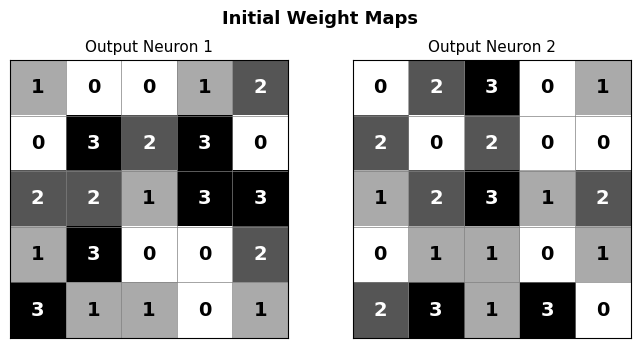

In [283]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
plot_weight_map(axes[0], weights[('initial', 1)], 'Output Neuron 1')
plot_weight_map(axes[1], weights[('initial', 2)], 'Output Neuron 2')
fig.suptitle('Initial Weight Maps', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('weights_initial.png', dpi=150, bbox_inches='tight')
plt.show()

## Weight Maps After Training on Digit 0

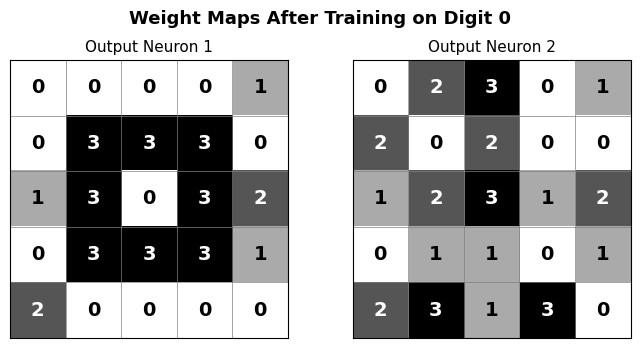

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
plot_weight_map(axes[0], weights[('after_train0', 1)], 'Output Neuron 1')
plot_weight_map(axes[1], weights[('after_train0', 2)], 'Output Neuron 2')
fig.suptitle('Weight Maps After Training on Digit 0', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('weights_after_train0.png', dpi=150, bbox_inches='tight')
plt.show()

## Weight Maps After Training on Digit 1 (Final Trained Weights)

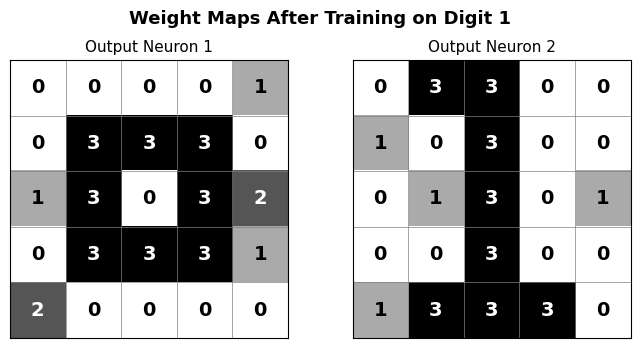

In [285]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
plot_weight_map(axes[0], weights[('after_train1', 1)], 'Output Neuron 1')
plot_weight_map(axes[1], weights[('after_train1', 2)], 'Output Neuron 2')
fig.suptitle('Weight Maps After Training on Digit 1', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('weights_after_train1.png', dpi=150, bbox_inches='tight')
plt.show()

## All Weight Maps Side-by-Side

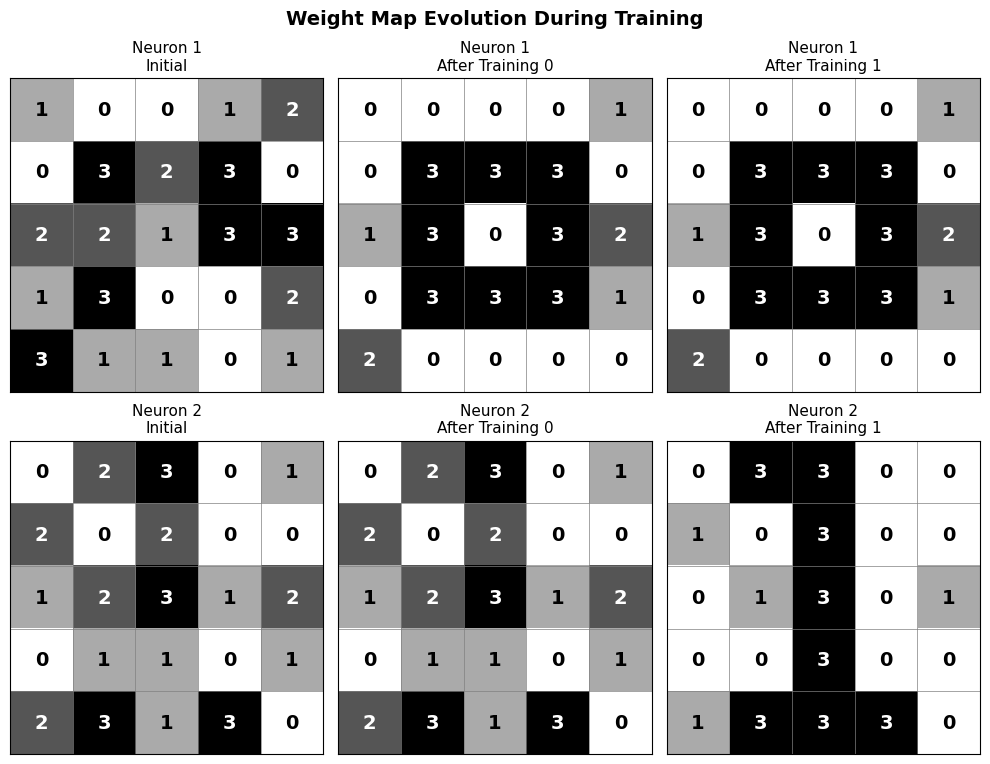

In [286]:
phases = ['initial', 'after_train0', 'after_train1']
titles = ['Initial', 'After Training 0', 'After Training 1']

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for col, (phase, title) in enumerate(zip(phases, titles)):
    plot_weight_map(axes[0, col], weights[(phase, 1)], f'Neuron 1\n{title}')
    plot_weight_map(axes[1, col], weights[(phase, 2)], f'Neuron 2\n{title}')

fig.suptitle('Weight Map Evolution During Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('weights_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Membrane Potential & Spike Train Waveforms

In [287]:
# Parse per-cycle data for each phase
phase_names = [
    'Phase 1: Training with digit 0',
    'Phase 2: Training with digit 1',
    'Phase 3: Testing with digit 0',
    'Phase 4: Testing with digit 1',
]

phases_data = {}
current_phase = None

for line in output.splitlines():
    # Detect phase headers
    for pname in phase_names:
        if pname in line:
            current_phase = pname
            phases_data[current_phase] = {'t': [], 'V1': [], 'V2': [], 's1': [], 's2': []}

    # Parse per-cycle lines
    if current_phase:
        m = re.match(r'\s+t=\s*(\d+):\s+V1=\s*(\d+)\s+V2=\s*(\d+)\s+spike1=(\d)\s+spike2=(\d)', line)
        if m:
            phases_data[current_phase]['t'].append(int(m.group(1)))
            phases_data[current_phase]['V1'].append(int(m.group(2)))
            phases_data[current_phase]['V2'].append(int(m.group(3)))
            phases_data[current_phase]['s1'].append(int(m.group(4)))
            phases_data[current_phase]['s2'].append(int(m.group(5)))

# Convert to numpy
for key in phases_data:
    for field in phases_data[key]:
        phases_data[key][field] = np.array(phases_data[key][field])

# Verify
for pname in phase_names:
    d = phases_data[pname]
    print(f"{pname}: {len(d['t'])} cycles, spikes N1={d['s1'].sum()} N2={d['s2'].sum()}")

Phase 1: Training with digit 0: 20 cycles, spikes N1=2 N2=0
Phase 2: Training with digit 1: 20 cycles, spikes N1=0 N2=2
Phase 3: Testing with digit 0: 20 cycles, spikes N1=2 N2=0
Phase 4: Testing with digit 1: 20 cycles, spikes N1=0 N2=2


In [288]:
V_THETA = 65
V_REST = 6

# Input firing sequences (MSB first, 20 bits)
WHITE_SEQ = [int(b) for b in '01000000100000000010']
BLACK_SEQ = [int(b) for b in '01010100010101000101']

def plot_phase(axes, data, title):
    """Plot V_mem waveform, spike raster, and input sequences for one phase."""
    ax_v, ax_s, ax_in = axes
    t = data['t']

    # --- Membrane potential ---
    ax_v.step(t, data['V1'], where='post', color='#1f77b4', linewidth=1.5, label='Neuron 1')
    ax_v.step(t, data['V2'], where='post', color='#d62728', linewidth=1.5, label='Neuron 2')
    ax_v.axhline(V_THETA, color='gray', linestyle='--', linewidth=1, label=f'$V_\\theta$ = {V_THETA}')
    ax_v.axhline(V_REST, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax_v.set_ylabel('$V_{mem}$')
    ax_v.set_title(title, fontsize=11, fontweight='bold')
    ax_v.legend(fontsize=8, loc='upper right')
    ax_v.set_xlim(0.5, 20.5)
    ax_v.set_ylim(0, max(data['V1'].max(), data['V2'].max()) + 10)
    ax_v.set_xticks(range(1, 21))
    ax_v.tick_params(labelbottom=False)

    # --- Spike raster ---
    s1_times = t[data['s1'] == 1]
    s2_times = t[data['s2'] == 1]
    ax_s.eventplot([s1_times, s2_times], lineoffsets=[1, 0], linelengths=0.6,
                   colors=['#1f77b4', '#d62728'], linewidths=2)
    ax_s.set_yticks([0, 1])
    ax_s.set_yticklabels(['N2', 'N1'], fontsize=9)
    ax_s.set_ylabel('Spikes', fontsize=9)
    ax_s.set_xlim(0.5, 20.5)
    ax_s.set_ylim(-0.5, 1.5)
    ax_s.set_xticks(range(1, 21))
    ax_s.tick_params(labelbottom=False)

    # --- Input firing sequences ---
    black_times = [i + 1 for i, b in enumerate(BLACK_SEQ) if b == 1]
    white_times = [i + 1 for i, b in enumerate(WHITE_SEQ) if b == 1]
    ax_in.eventplot([black_times, white_times], lineoffsets=[1, 0], linelengths=0.6,
                    colors=['black', '#888888'], linewidths=2)
    ax_in.set_yticks([0, 1])
    ax_in.set_yticklabels(['White', 'Black'], fontsize=9)
    ax_in.set_xlabel('Time step')
    ax_in.set_ylabel('Input', fontsize=9)
    ax_in.set_xlim(0.5, 20.5)
    ax_in.set_ylim(-0.5, 1.5)
    ax_in.set_xticks(range(1, 21))

### Training: Digit 0

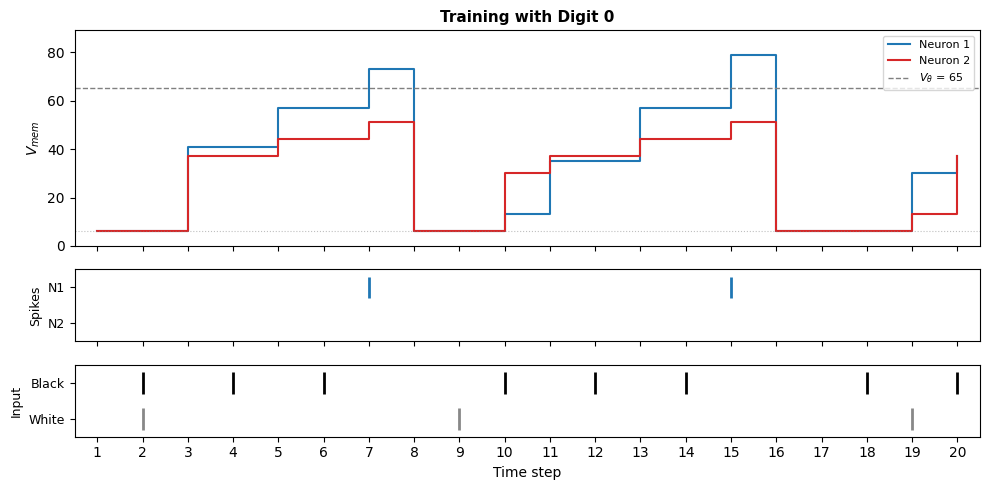

In [289]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
plot_phase(axes, phases_data['Phase 1: Training with digit 0'], 'Training with Digit 0')
plt.tight_layout()
#plt.savefig('waveform_train0.png', dpi=150, bbox_inches='tight')
plt.show()

### Training: Digit 1

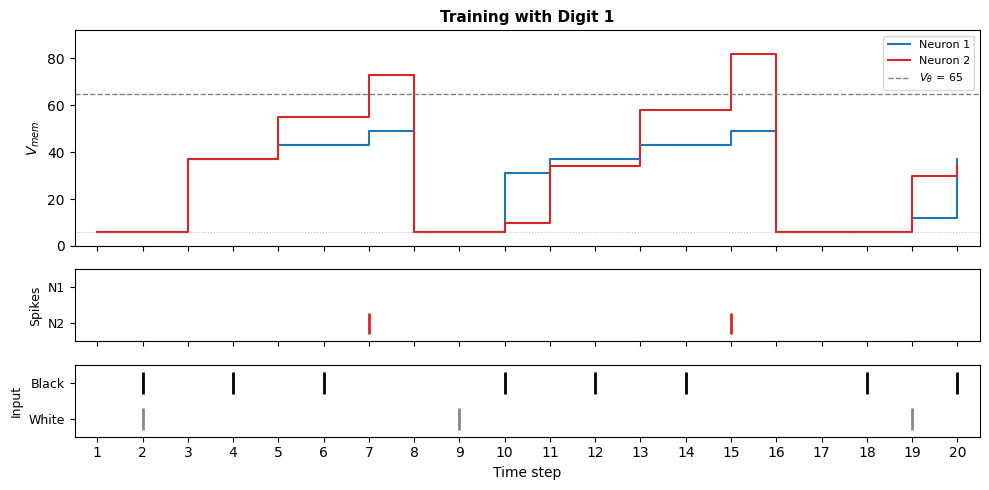

In [290]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
plot_phase(axes, phases_data['Phase 2: Training with digit 1'], 'Training with Digit 1')
plt.tight_layout()
#plt.savefig('waveform_train1.png', dpi=150, bbox_inches='tight')
plt.show()

### Testing: Digit 0

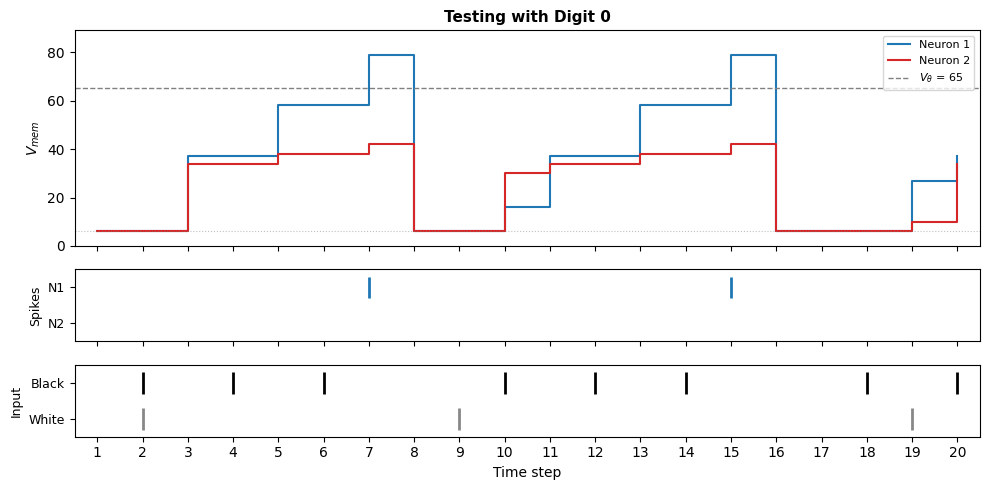

In [291]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
plot_phase(axes, phases_data['Phase 3: Testing with digit 0'], 'Testing with Digit 0')
plt.tight_layout()
#plt.savefig('waveform_test0.png', dpi=150, bbox_inches='tight')
plt.show()

### Testing: Digit 1

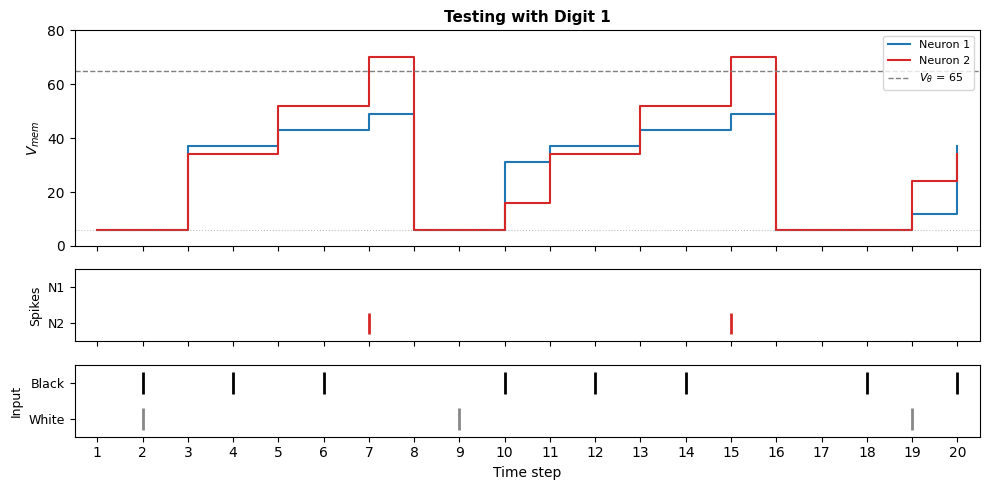

In [292]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
plot_phase(axes, phases_data['Phase 4: Testing with digit 1'], 'Testing with Digit 1')
plt.tight_layout()
#plt.savefig('waveform_test1.png', dpi=150, bbox_inches='tight')
plt.show()

### Spike Count Summary

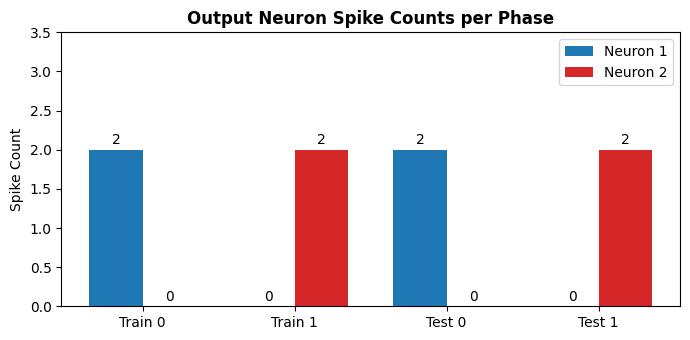

In [293]:
short_names = ['Train 0', 'Train 1', 'Test 0', 'Test 1']
n1_counts = [phases_data[p]['s1'].sum() for p in phase_names]
n2_counts = [phases_data[p]['s2'].sum() for p in phase_names]

x = np.arange(len(short_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 3.5))
bars1 = ax.bar(x - width/2, n1_counts, width, label='Neuron 1', color='#1f77b4')
bars2 = ax.bar(x + width/2, n2_counts, width, label='Neuron 2', color='#d62728')

ax.set_ylabel('Spike Count')
ax.set_title('Output Neuron Spike Counts per Phase', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.legend()
ax.bar_label(bars1, padding=2)
ax.bar_label(bars2, padding=2)
ax.set_ylim(0, max(max(n1_counts), max(n2_counts)) + 1.5)

plt.tight_layout()
#plt.savefig('spike_counts.png', dpi=150, bbox_inches='tight')
plt.show()